# TD3 — Prétraitement EEG : des signaux connus aux signaux du dataset CL-Drive

## Objectifs pédagogiques

Ce TD est consacré au **prétraitement des signaux EEG**. Il prépare directement le projet final sur l'estimation de la charge cognitive du conducteur à partir du dataset CL-Drive.

À la fin du TD, vous devez être capables de :

1. expliquer pourquoi un signal EEG doit être prétraité ;
2. comprendre le rôle d'un filtre passe-bande ;
3. comprendre le rôle d'un filtre notch ;
4. tester une chaîne de prétraitement sur des signaux synthétiques connus ;
5. appliquer la même logique à des signaux EEG du dataset ;
6. comparer les signaux avant et après traitement dans le domaine temporel et fréquentiel ;
7. formaliser une fonction de prétraitement EEG réutilisable dans le projet.

Dans le papier CL-Drive, l'EEG est acquis avec un casque Muse à 4 canaux, échantillonné à **256 Hz**. Le prétraitement EEG indiqué par les auteurs utilise un filtre passe-bande Butterworth d'ordre 2 entre **0.4 Hz et 75 Hz**, puis un filtre notch à **60 Hz** avec facteur de qualité **30**.

## 1. Pourquoi prétraiter un signal EEG ?

Un signal EEG brut contient l'activité électrique mesurée au niveau du cuir chevelu, mais aussi des perturbations :

- dérive lente de la ligne de base ;
- bruit secteur 50 Hz ou 60 Hz ;
- bruit haute fréquence ;
- artefacts.

Le prétraitement ne sert pas à embellir le signal. Il sert à produire un signal plus exploitable pour la segmentation, l'extraction de features et la classification.

Chaîne visée :

$$
\text{EEG brut} \rightarrow \text{gestion des valeurs manquantes} \rightarrow \text{passe-bande} \rightarrow \text{notch} \rightarrow \text{EEG prétraité}
$$

### Question 1

Citer au moins trois sources d'artefacts dans un signal EEG brut.

### Réponse

- **Artefacts musculaires (EMG)** : les contractions des muscles du visage, de la mâchoire ou du cou génèrent une activité électrique haute fréquence qui se superpose au signal EEG.
- **Artefacts oculaires (EOG)** : les clignements et mouvements des yeux produisent de grandes variations lentes, surtout visibles sur les canaux frontaux AF7 et AF8.
- **Artefacts de mouvement** : un déplacement de la tête ou un glissement de l'électrode provoque une variation brusque de l'impédance électrode-peau, créant des sauts d'amplitude dans le signal.


## 2. Tester le prétraitement sur des signaux connus

Avant d'appliquer une chaîne de traitement à un EEG réel, il est utile de la tester sur un signal synthétique dont on connaît exactement le contenu fréquentiel.

On construira un signal contenant :

$$
x(t) = x_{lent}(t) + x_{alpha}(t) + x_{beta}(t) + x_{secteur}(t) + b(t)
$$

avec :

- une dérive lente à 0.2 Hz ;
- une composante alpha à 10 Hz ;
- une composante beta à 25 Hz ;
- une composante de bruit secteur à 50 Hz ou 60 Hz ;
- un bruit aléatoire.

Si le traitement est correct, la dérive lente et le bruit secteur doivent être fortement réduits, tandis que les composantes utiles doivent rester visibles.

### Question 2

Pourquoi commencer par un signal synthétique avant un signal EEG réel ?

### Réponse

Parce qu'avec un signal synthétique, on connaît exactement son contenu fréquentiel : on sait quelles composantes on a introduites (dérive à 0.2 Hz, alpha à 10 Hz, bruit secteur à 60 Hz…) et donc ce que le filtre doit conserver ou supprimer. Si le résultat ne correspond pas à ce qu'on attend, le bug vient forcément du code du filtre, pas des données.

Avec un EEG réel, le contenu fréquentiel est inconnu a priori et variable selon le sujet. Un résultat inattendu pourrait venir soit du filtre, soit de la nature du signal lui-même, ce qui rend le débogage beaucoup plus difficile.

Le signal synthétique sert donc de cas de test contrôlé : il valide que la chaîne de prétraitement fonctionne correctement avant de l'appliquer aux données réelles.

### Activité 1 — Générer un signal synthétique

Consignes méthodologiques :

1. créer un axe temporel de 20 secondes avec `fs = 256 Hz` ;
2. ajouter une sinusoïde lente à 0.2 Hz ;
3. ajouter une sinusoïde à 10 Hz ;
4. ajouter une sinusoïde à 25 Hz ;
5. ajouter une sinusoïde à 60 Hz ;
6. ajouter un bruit gaussien ;
7. tracer le signal temporel ;
8. calculer la PSD avec `scipy.signal.welch`.

Fonctions utiles : `np.arange`, `np.sin`, `np.random.normal`, `plt.plot`, `welch`.

Nombre d'échantillons : 5120  (= 20 s × 256 Hz)


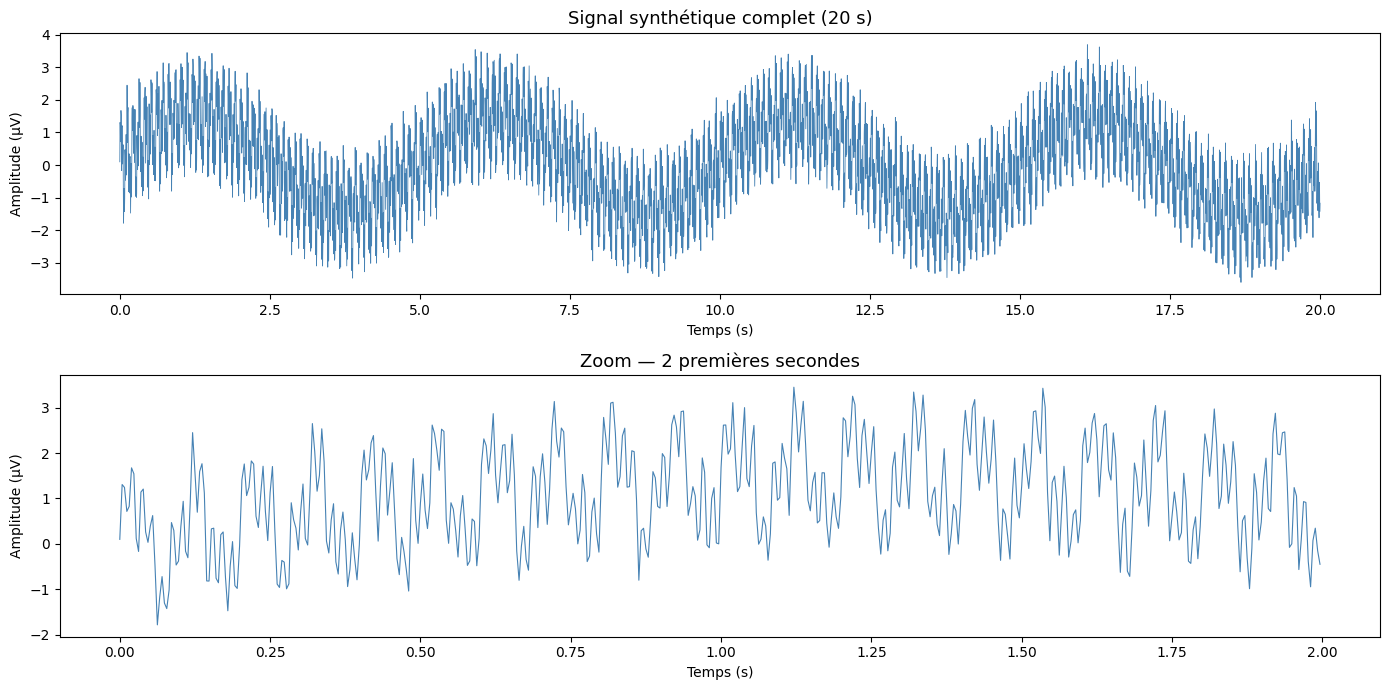

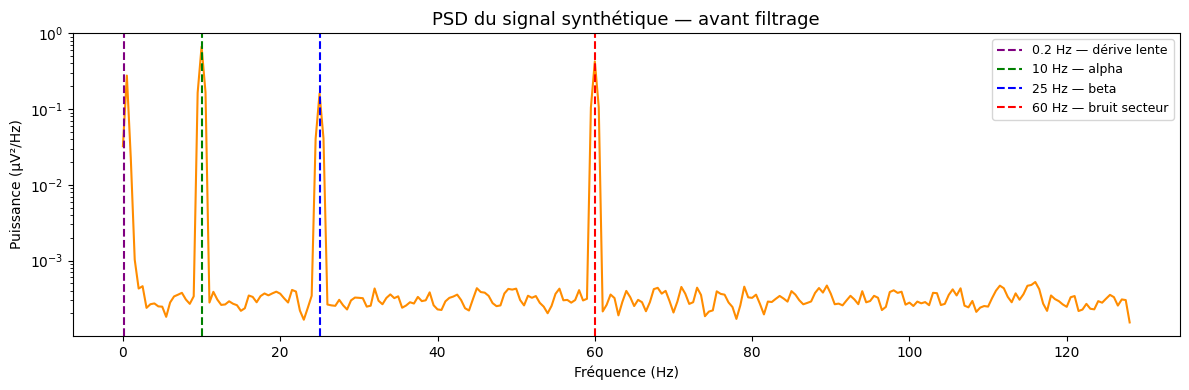


Composantes présentes dans le signal :
  Dérive lente  : 0.2 Hz  — amplitude 1.5 µV
  Alpha         : 10 Hz   — amplitude 1.0 µV
  Beta          : 25 Hz   — amplitude 0.5 µV
  Bruit secteur : 60 Hz   — amplitude 0.8 µV
  Bruit blanc   : toutes fréquences — amplitude 0.2 µV

Objectif du filtrage : supprimer 0.2 Hz et 60 Hz, conserver 10 Hz et 25 Hz.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ── Paramètres de base ────────────────────────────────────────────────────────
fs = 256          # fréquence d'échantillonnage en Hz (256 mesures par seconde)
duree = 20        # durée du signal en secondes

# ── Étape 1 : axe temporel ────────────────────────────────────────────────────
# np.arange(debut, fin, pas) crée une suite de valeurs régulièrement espacées.
# Le pas 1/fs correspond à l'intervalle entre deux échantillons consécutifs.
# → pour fs=256 Hz, le pas vaut 1/256 ≈ 0.0039 s
t = np.arange(0, duree, 1 / fs)
# t est un tableau de 20 * 256 = 5120 valeurs : [0, 0.0039, 0.0078, ..., 19.996]
print(f"Nombre d'échantillons : {len(t)}  (= {duree} s × {fs} Hz)")

# ── Étapes 2 à 6 : construire le signal composante par composante ─────────────
# Une sinusoïde de fréquence f s'écrit : A * sin(2π * f * t)
# On additionne toutes les composantes pour former x(t).

# Composante 1 — dérive lente à 0.2 Hz (simule la dérive de la ligne de base)
# Amplitude 1.5 µV, fréquence très basse → sera supprimée par le filtre passe-bande
x_lent   = 1.5 * np.sin(2 * np.pi * 0.2 * t)

# Composante 2 — rythme alpha à 10 Hz (activité EEG utile)
# Amplitude 1.0 µV → doit être conservée après filtrage
x_alpha  = 1.0 * np.sin(2 * np.pi * 10  * t)

# Composante 3 — rythme beta à 25 Hz (activité EEG utile)
# Amplitude 0.5 µV → doit être conservée après filtrage
x_beta   = 0.5 * np.sin(2 * np.pi * 25  * t)

# Composante 4 — bruit secteur à 60 Hz (interférence du réseau électrique)
# Amplitude 0.8 µV → sera supprimée par le filtre notch
x_secteur = 0.8 * np.sin(2 * np.pi * 60  * t)

# Composante 5 — bruit gaussien (bruit de mesure aléatoire)
# np.random.normal(moyenne, écart-type, nombre_de_points)
np.random.seed(42)   # fixe pour avoir les mêmes résultats à chaque exécution
x_bruit  = 0.2 * np.random.normal(0, 1, size=len(t))

# Signal final = somme de toutes les composantes
x = x_lent + x_alpha + x_beta + x_secteur + x_bruit

# ── Étape 7 : tracé du signal temporel ───────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Graphique du haut — signal complet sur 20 secondes
axes[0].plot(t, x, color="steelblue", linewidth=0.6)
axes[0].set_title("Signal synthétique complet (20 s)", fontsize=13)
axes[0].set_xlabel("Temps (s)")
axes[0].set_ylabel("Amplitude (µV)")

# Graphique du bas — zoom sur les 2 premières secondes
# On voit mieux les différentes oscillations en zoomant
mask = t < 2          # masque booléen : True pour t < 2 s
axes[1].plot(t[mask], x[mask], color="steelblue", linewidth=0.8)
axes[1].set_title("Zoom — 2 premières secondes", fontsize=13)
axes[1].set_xlabel("Temps (s)")
axes[1].set_ylabel("Amplitude (µV)")

plt.tight_layout()
plt.show()

# ── Étape 8 : densité spectrale de puissance (PSD) avec Welch ─────────────────
# welch() découpe le signal en sous-fenêtres, calcule un spectre sur chacune,
# puis les moyenne → estimation plus stable qu'une simple FFT.
# nperseg = taille de chaque sous-fenêtre (ici 2 secondes de signal)
freqs, psd = welch(x, fs=fs, nperseg=fs * 2)

plt.figure(figsize=(12, 4))
plt.semilogy(freqs, psd, color="darkorange")   # axe Y en échelle log pour voir les petits pics
plt.title("PSD du signal synthétique — avant filtrage", fontsize=13)
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Puissance (µV²/Hz)")

# On marque les composantes connues avec des lignes verticales
plt.axvline(0.2,  color="purple", linestyle="--", label="0.2 Hz — dérive lente")
plt.axvline(10,   color="green",  linestyle="--", label="10 Hz — alpha")
plt.axvline(25,   color="blue",   linestyle="--", label="25 Hz — beta")
plt.axvline(60,   color="red",    linestyle="--", label="60 Hz — bruit secteur")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Résumé de ce qu'on voit ───────────────────────────────────────────────────
print("\nComposantes présentes dans le signal :")
print(f"  Dérive lente  : 0.2 Hz  — amplitude 1.5 µV")
print(f"  Alpha         : 10 Hz   — amplitude 1.0 µV")
print(f"  Beta          : 25 Hz   — amplitude 0.5 µV")
print(f"  Bruit secteur : 60 Hz   — amplitude 0.8 µV")
print(f"  Bruit blanc   : toutes fréquences — amplitude 0.2 µV")
print(f"\nObjectif du filtrage : supprimer 0.2 Hz et 60 Hz, conserver 10 Hz et 25 Hz.")

## 3. Filtre passe-bande Butterworth

Un filtre passe-bande conserve les fréquences situées dans une bande choisie et atténue les autres.

Dans CL-Drive, la bande EEG retenue est :

$$
0.4 \leq f \leq 75 \quad \text{Hz}
$$

Pour un signal échantillonné à $ f_s $, la fréquence de Nyquist vaut :

$$
f_N = \frac{f_s}{2}
$$

Les fréquences de coupure doivent être normalisées :

$$
W_{low}=\frac{f_{low}}{f_N}, \qquad W_{high}=\frac{f_{high}}{f_N}
$$

Fonctions utiles :

- `scipy.signal.butter` pour concevoir le filtre ;
- `scipy.signal.sosfiltfilt` pour filtrer sans déphasage notable ;
- `scipy.signal.welch` pour vérifier l'effet fréquentiel.

### Question 3

Pourquoi utiliser `filtfilt` ou `sosfiltfilt` pour une analyse hors ligne ?

### Réponse

Un filtre classique (`lfilter`) introduit un **déphasage** : chaque fréquence est retardée d'un certain nombre d'échantillons, ce qui décale les événements dans le temps et fausse l'alignement entre le signal filtré et les labels.

`filtfilt` (et son équivalent stable `sosfiltfilt`) applique le filtre **deux fois** : une fois en avant, une fois en arrière. Les deux passages se compensent exactement, ce qui donne un déphasage nul. Le signal filtré reste parfaitement aligné temporellement avec le signal original.

C'est possible uniquement **hors ligne** (sur un enregistrement complet), car on a besoin des échantillons futurs pour le passage en arrière. En temps réel, on ne peut pas utiliser `filtfilt`.

### Question 4

Calculer la fréquence de Nyquist pour `fs = 256 Hz`.

### Réponse

$$f_N = \frac{f_s}{2} = \frac{256}{2} = 128 \text{ Hz}$$

La fréquence de Nyquist est la fréquence maximale représentable dans un signal échantillonné à 256 Hz. Toute composante au-dessus de 128 Hz ne peut pas être correctement représentée et provoquerait un repliement spectral (aliasing).

### Activité 2 — Algorithme du filtre passe-bande

Écrire une fonction de filtre passe-bande.

Algorithme :

1. fixer `lowcut = 0.4` ;
2. fixer `highcut = 75` ;
3. fixer `order = 2` ;
4. calculer `nyquist = fs / 2` ;
5. normaliser les fréquences ;
6. créer le filtre avec `butter(..., output="sos")` ;
7. appliquer le filtre avec `sosfiltfilt` ;
8. comparer signal brut et signal filtré.

Fréquence de Nyquist : 128.0 Hz
Fréquences normalisées : low = 0.0031, high = 0.5859


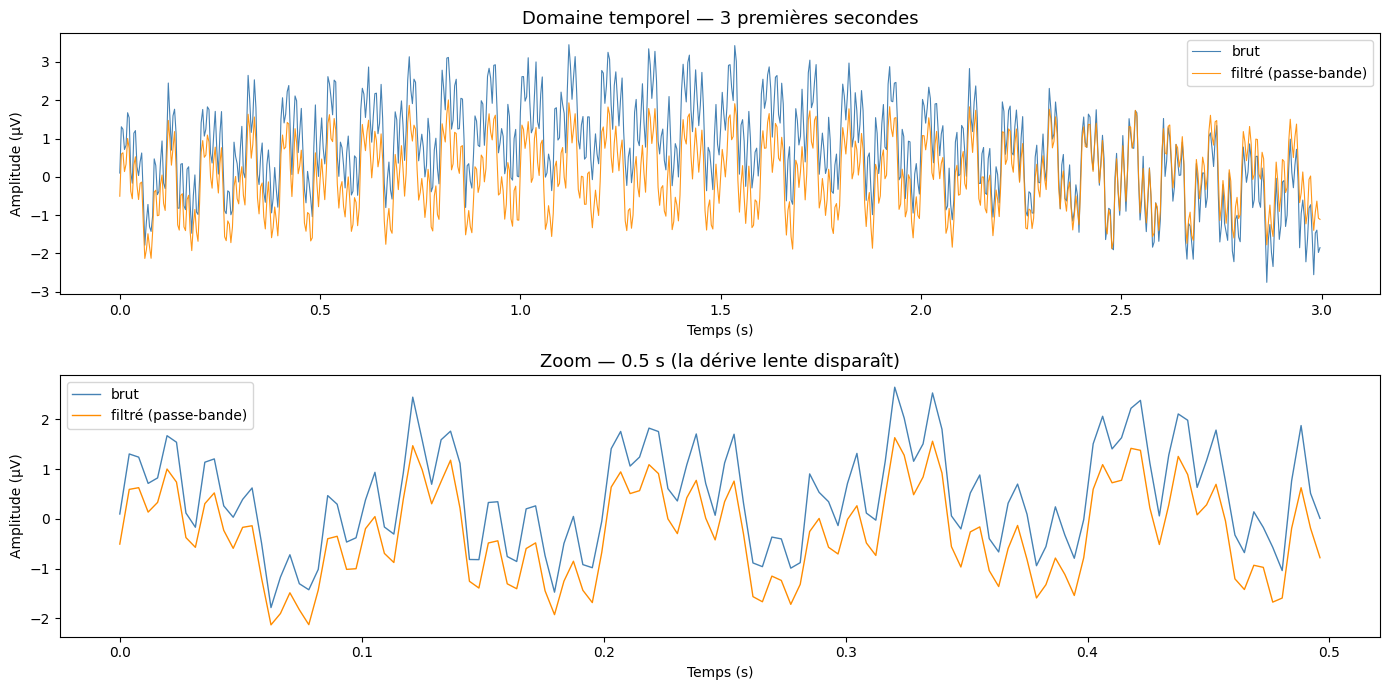

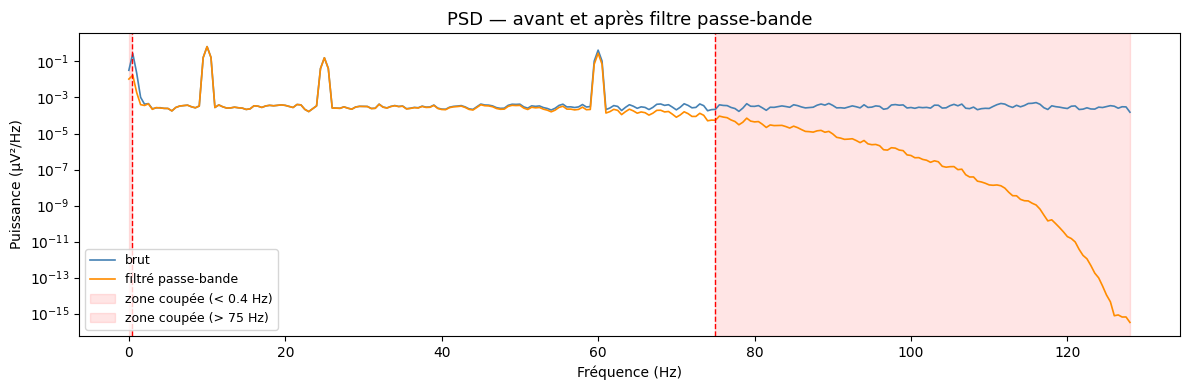

Ce qu'on doit observer :
  ✓ La dérive à 0.2 Hz est supprimée (pic disparu sur la PSD)
  ✓ Le pic alpha à 10 Hz est conservé
  ✓ Le pic beta à 25 Hz est conservé
  ✗ Le bruit secteur à 60 Hz reste présent (pas encore traité par le notch)


In [ ]:
from scipy.signal import butter, sosfiltfilt, welch
import numpy as np
import matplotlib.pyplot as plt

# ── Étapes 1 à 3 : paramètres du filtre ──────────────────────────────────────
lowcut  = 0.4   # fréquence de coupure basse  en Hz  → tout ce qui est EN DESSOUS est supprimé
highcut = 75.0  # fréquence de coupure haute  en Hz  → tout ce qui est AU DESSUS est supprimé
order   = 2     # ordre du filtre Butterworth  → plus l'ordre est élevé, plus la coupure est nette
                # mais un ordre trop élevé peut créer des instabilités numériques

# ── Étape 4 : fréquence de Nyquist ───────────────────────────────────────────
# scipy attend des fréquences normalisées entre 0 et 1,
# où 1 correspond à la fréquence de Nyquist (= fs/2).
# On doit donc diviser nos fréquences de coupure par nyquist avant de les passer à butter().
nyquist = fs / 2.0   # = 256 / 2 = 128 Hz
print(f"Fréquence de Nyquist : {nyquist} Hz")

# ── Étape 5 : normalisation des fréquences ────────────────────────────────────
# butter() attend des fréquences dans [0, 1] (normalisées par rapport à Nyquist)
low  = lowcut  / nyquist   # 0.4  / 128 ≈ 0.003
high = highcut / nyquist   # 75.0 / 128 ≈ 0.586
print(f"Fréquences normalisées : low = {low:.4f}, high = {high:.4f}")

# ── Étape 6 : conception du filtre Butterworth ────────────────────────────────
# butter() renvoie les coefficients du filtre.
# On utilise output="sos" (Second-Order Sections) plutôt que les coefficients
# b, a classiques car la forme SOS est numériquement plus stable pour les filtres d'ordre élevé.
sos = butter(order, [low, high], btype="band", output="sos")
# sos est un tableau 2D : chaque ligne est un filtre du 2e ordre en cascade

# ── Étape 7 : appliquer le filtre au signal ───────────────────────────────────
# sosfiltfilt applique le filtre en avant puis en arrière → déphasage nul
x_bp = sosfiltfilt(sos, x)
# x_bp est le signal filtré (même longueur que x)

# ── Étape 8 : comparaison signal brut vs signal filtré ────────────────────────

# — Domaine temporel —
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

mask = t < 3   # zoom sur les 3 premières secondes pour mieux voir

axes[0].plot(t[mask], x[mask],    color="steelblue",  linewidth=0.8, label="brut")
axes[0].plot(t[mask], x_bp[mask], color="darkorange", linewidth=0.8, label="filtré (passe-bande)", alpha=0.9)
axes[0].set_title("Domaine temporel — 3 premières secondes", fontsize=13)
axes[0].set_xlabel("Temps (s)")
axes[0].set_ylabel("Amplitude (µV)")
axes[0].legend()

# Zoom encore plus court pour voir la superposition des oscillations
mask2 = t < 0.5
axes[1].plot(t[mask2], x[mask2],    color="steelblue",  linewidth=1.0, label="brut")
axes[1].plot(t[mask2], x_bp[mask2], color="darkorange", linewidth=1.0, label="filtré (passe-bande)")
axes[1].set_title("Zoom — 0.5 s (la dérive lente disparaît)", fontsize=13)
axes[1].set_xlabel("Temps (s)")
axes[1].set_ylabel("Amplitude (µV)")
axes[1].legend()

plt.tight_layout()
plt.show()

# — Domaine fréquentiel (PSD) —
freqs, psd_brut = welch(x,    fs=fs, nperseg=fs * 2)
freqs, psd_bp   = welch(x_bp, fs=fs, nperseg=fs * 2)

plt.figure(figsize=(12, 4))
plt.semilogy(freqs, psd_brut, color="steelblue",  label="brut",            linewidth=1.2)
plt.semilogy(freqs, psd_bp,   color="darkorange", label="filtré passe-bande", linewidth=1.2)

# Zones supprimées par le filtre
plt.axvspan(0,      lowcut,  alpha=0.1, color="red",   label="zone coupée (< 0.4 Hz)")
plt.axvspan(highcut, 128,    alpha=0.1, color="red",   label="zone coupée (> 75 Hz)")
plt.axvline(lowcut,  color="red",  linestyle="--", linewidth=1)
plt.axvline(highcut, color="red",  linestyle="--", linewidth=1)

plt.title("PSD — avant et après filtre passe-bande", fontsize=13)
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Puissance (µV²/Hz)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Ce qu'on attend ──────────────────────────────────────────────────────────
print("Ce qu'on doit observer :")
print("  ✓ La dérive à 0.2 Hz est supprimée (pic disparu sur la PSD)")
print("  ✓ Le pic alpha à 10 Hz est conservé")
print("  ✓ Le pic beta à 25 Hz est conservé")
print("  ✗ Le bruit secteur à 60 Hz reste présent (pas encore traité par le notch)")

## 4. Filtre notch

Un filtre notch est contrôlé par :

- sa fréquence cible `notch_freq` ;
- son facteur de qualité `Q`.

Dans le papier, `Q = 30`.

Fonctions utiles : `scipy.signal.iirnotch`, puis `scipy.signal.filtfilt`.

### Question 5

Pourquoi CL-Drive utilise-t-il un notch à 60 Hz alors qu'en France on utilise plutôt 50 Hz ?

### Réponse

Parce que le dataset CL-Drive a été collecté au **Canada** (Queen's University, Ontario), où le réseau électrique fonctionne à **60 Hz**, contrairement à l'Europe (dont la France) où il fonctionne à **50 Hz**.

Le bruit secteur présent dans l'enregistrement est donc à 60 Hz, et c'est cette fréquence qu'il faut supprimer avec le filtre notch. Appliquer un notch à 50 Hz sur ces données serait inutile car il n'y a pas de perturbation à cette fréquence, et on atténuerait inutilement une partie du signal EEG.

### Question 6

Pourquoi ne faut-il pas appliquer automatiquement un notch sans regarder la PSD ?

### Réponse

Pour deux raisons :

1. **Le pic secteur n'est pas toujours présent.** Si l'enregistrement a été réalisé avec un matériel bien blindé ou dans un environnement peu bruité, il peut ne pas y avoir de contamination à 60 Hz. Appliquer un notch dans ce cas atténue inutilement une portion du signal EEG (notamment une partie de la bande gamma).

2. **La fréquence exacte du pic peut être légèrement décalée.** En pratique, le réseau n'est pas parfaitement à 50 ou 60 Hz, et des harmoniques peuvent apparaître (120 Hz, 180 Hz…). Regarder la PSD permet de confirmer la présence du pic, d'identifier sa fréquence exacte, et de décider si un notch est vraiment nécessaire et à quelle fréquence l'appliquer.

### Activité 3 — Algorithme du notch

1. choisir `notch_freq` ;
2. choisir `Q = 30` ;
3. créer le filtre avec `iirnotch` ;
4. appliquer `filtfilt` ;
5. comparer les PSD avant/après ;
6. vérifier que le pic à 60 Hz diminue.

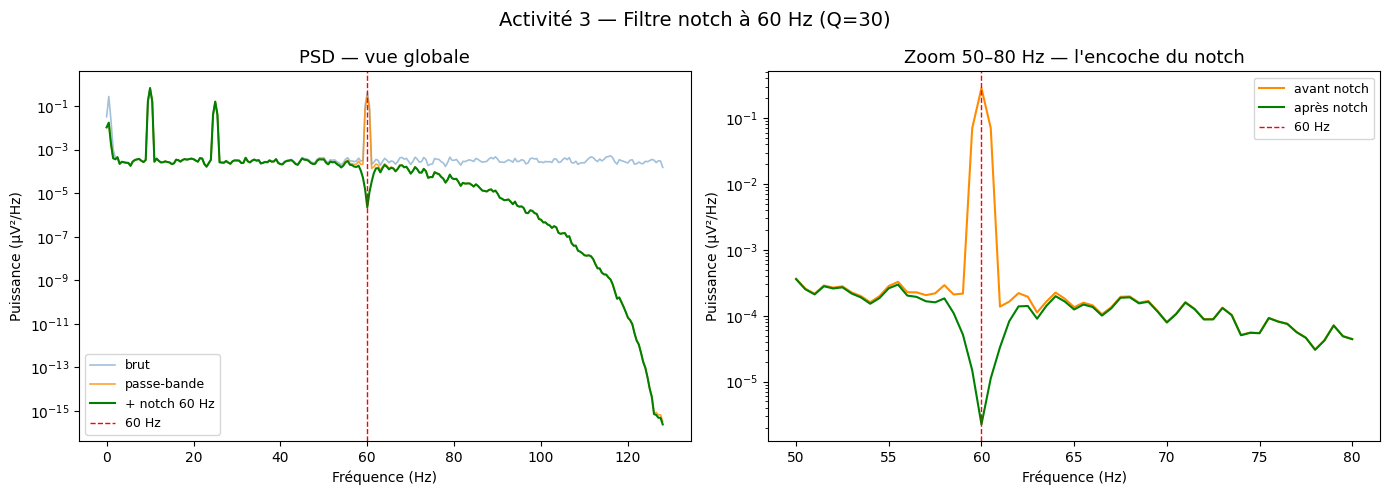

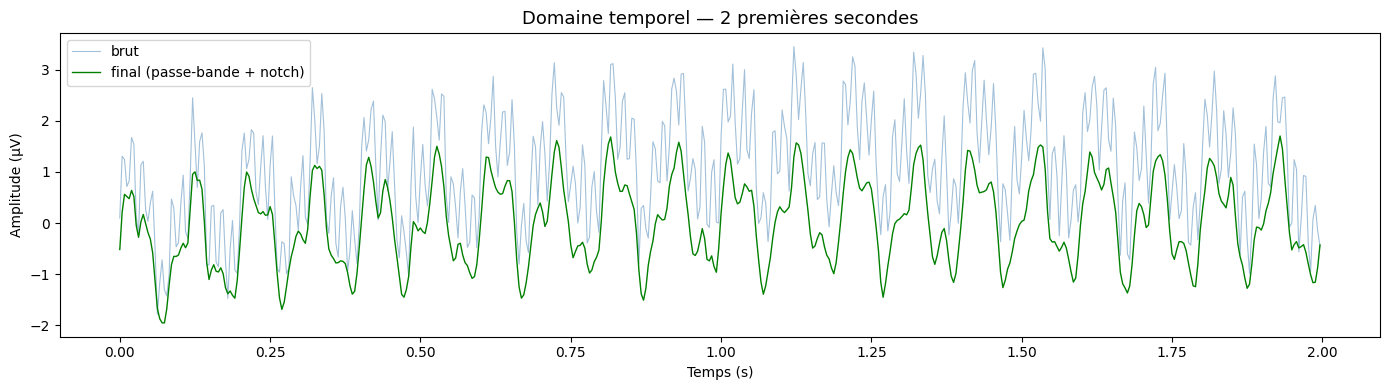

Puissance à 60 Hz — avant notch : 0.2850 µV²/Hz
Puissance à 60 Hz — après notch : 0.0000 µV²/Hz
Réduction : ×0.00001  (~51.1 dB atténués)

Résumé de la chaîne complète :
  x        → signal brut (dérive + alpha + beta + secteur + bruit)
  x_bp     → après passe-bande 0.4–75 Hz  (dérive supprimée)
  x_final  → après notch 60 Hz            (bruit secteur supprimé)


In [ ]:
from scipy.signal import iirnotch, filtfilt, welch
import numpy as np
import matplotlib.pyplot as plt

# ── Étape 1 : fréquence cible du notch ───────────────────────────────────────
# Le dataset CL-Drive est canadien → réseau électrique à 60 Hz
notch_freq = 60.0   # Hz

# ── Étape 2 : facteur de qualité Q ───────────────────────────────────────────
# Q contrôle la largeur de l'encoche : largeur ≈ notch_freq / Q
# Q = 30  →  largeur ≈ 60 / 30 = 2 Hz  (encoche de 59 à 61 Hz)
# Plus Q est grand → encoche plus étroite → moins de signal EEG sacrifié
Q = 30

# ── Étape 3 : conception du filtre notch ─────────────────────────────────────
# iirnotch attend une fréquence normalisée par Nyquist (même logique que butter)
nyquist   = fs / 2.0
freq_norm = notch_freq / nyquist   # 60 / 128 ≈ 0.469

b_notch, a_notch = iirnotch(freq_norm, Q)
# Contrairement à butter (qui renvoie des SOS), iirnotch renvoie des coefficients b, a
# → on utilise filtfilt (et non sosfiltfilt) pour appliquer ce filtre

# ── Étape 4 : appliquer le notch au signal déjà passe-bandé ──────────────────
# On applique le notch sur x_bp (résultat de l'Activité 2)
# Chaîne complète : brut → passe-bande → notch
x_final = filtfilt(b_notch, a_notch, x_bp)

# ── Étapes 5 & 6 : comparer les PSD avant/après le notch ─────────────────────
freqs, psd_brut  = welch(x,       fs=fs, nperseg=fs * 2)
freqs, psd_bp    = welch(x_bp,    fs=fs, nperseg=fs * 2)
freqs, psd_final = welch(x_final, fs=fs, nperseg=fs * 2)

# — Vue globale (0–128 Hz) —
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogy(freqs, psd_brut,  color="steelblue",  linewidth=1.2, label="brut",          alpha=0.5)
axes[0].semilogy(freqs, psd_bp,    color="darkorange",  linewidth=1.2, label="passe-bande",   alpha=0.8)
axes[0].semilogy(freqs, psd_final, color="green",       linewidth=1.5, label="+ notch 60 Hz")
axes[0].axvline(60, color="red", linestyle="--", linewidth=1, label="60 Hz")
axes[0].set_title("PSD — vue globale", fontsize=13)
axes[0].set_xlabel("Fréquence (Hz)")
axes[0].set_ylabel("Puissance (µV²/Hz)")
axes[0].legend(fontsize=9)

# — Zoom 50–80 Hz : on voit clairement l'encoche —
mask_freq = (freqs >= 50) & (freqs <= 80)
axes[1].semilogy(freqs[mask_freq], psd_bp[mask_freq],    color="darkorange", linewidth=1.5, label="avant notch")
axes[1].semilogy(freqs[mask_freq], psd_final[mask_freq], color="green",      linewidth=1.5, label="après notch")
axes[1].axvline(60, color="red", linestyle="--", linewidth=1, label="60 Hz")
axes[1].set_title("Zoom 50–80 Hz — l'encoche du notch", fontsize=13)
axes[1].set_xlabel("Fréquence (Hz)")
axes[1].set_ylabel("Puissance (µV²/Hz)")
axes[1].legend(fontsize=9)

plt.suptitle("Activité 3 — Filtre notch à 60 Hz (Q=30)", fontsize=14)
plt.tight_layout()
plt.show()

# — Domaine temporel : signal brut vs signal final —
fig, ax = plt.subplots(figsize=(14, 4))
mask_t = t < 2
ax.plot(t[mask_t], x[mask_t],       color="steelblue", linewidth=0.8, label="brut",               alpha=0.5)
ax.plot(t[mask_t], x_final[mask_t], color="green",     linewidth=1.0, label="final (passe-bande + notch)")
ax.set_title("Domaine temporel — 2 premières secondes", fontsize=13)
ax.set_xlabel("Temps (s)")
ax.set_ylabel("Amplitude (µV)")
ax.legend()
plt.tight_layout()
plt.show()

# ── Vérification numérique ────────────────────────────────────────────────────
idx_60 = np.argmin(np.abs(freqs - 60))
p_avant = psd_bp[idx_60]
p_apres = psd_final[idx_60]
print(f"Puissance à 60 Hz — avant notch : {p_avant:.4f} µV²/Hz")
print(f"Puissance à 60 Hz — après notch : {p_apres:.4f} µV²/Hz")
print(f"Réduction : ×{p_apres/p_avant:.5f}  (~{10*np.log10(p_avant/p_apres):.1f} dB atténués)")

print("\nRésumé de la chaîne complète :")
print("  x        → signal brut (dérive + alpha + beta + secteur + bruit)")
print("  x_bp     → après passe-bande 0.4–75 Hz  (dérive supprimée)")
print("  x_final  → après notch 60 Hz            (bruit secteur supprimé)")

## 5. Fonction complète de prétraitement EEG

La fonction finale doit enchaîner :

1. conversion en tableau numérique ;
2. gestion des valeurs manquantes courtes ;
3. filtrage passe-bande ;
4. filtrage notch ;
5. retour du signal prétraité.

Paramètres recommandés pour CL-Drive :

| Paramètre | Valeur |
|---|---:|
| `fs` | 256 Hz |
| `lowcut` | 0.4 Hz |
| `highcut` | 75 Hz |
| `order of filter` | 2 |
| `notch_freq` | 60 Hz |
| `quality_factor` | 30 |

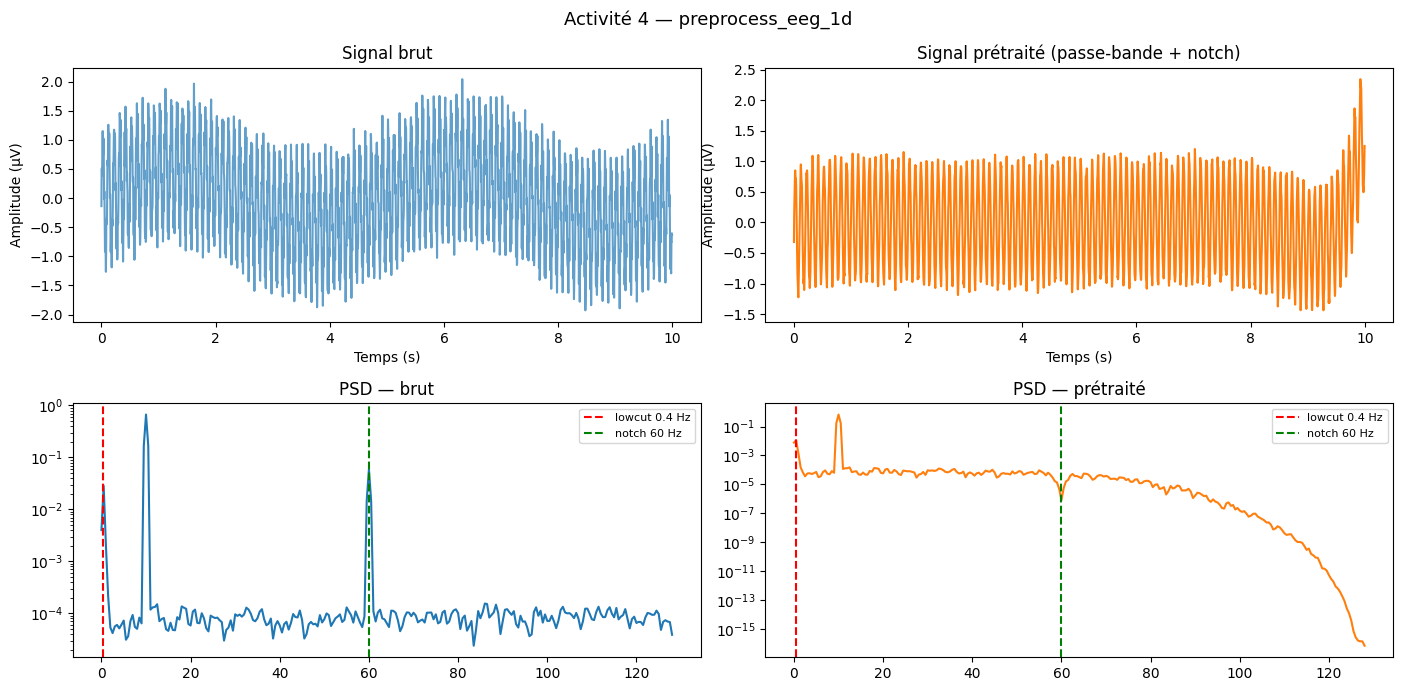

Longueur entrée  : 2560
Longueur sortie  : 2560


In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt


def preprocess_eeg_1d(signal, fs=256, lowcut=0.4, highcut=75.0, order=2,
                      notch_freq=60.0, quality_factor=30):
    """
    Prétraitement d'un canal EEG 1D (CL-Drive).

    Étapes :
      1. Conversion en tableau NumPy float64
      2. Filtre passe-bande Butterworth ordre 2 (0.4–75 Hz)
      3. Filtre notch (60 Hz, Q=30)

    Les segments contenant des NaN doivent être exclus en amont
    (conformément au papier CL-Drive, section IV.A).
    """
    sig = np.array(signal, dtype=np.float64)

    # Filtre passe-bande
    nyquist = fs / 2.0
    sos = butter(order, [lowcut / nyquist, highcut / nyquist], btype="band", output="sos")
    sig = sosfiltfilt(sos, sig)

    # Filtre notch
    b_notch, a_notch = iirnotch(notch_freq / nyquist, quality_factor)
    sig = filtfilt(b_notch, a_notch, sig)

    return sig


# --- Exemple sur signal synthétique ---
if __name__ == "__main__" or True:
    fs = 256
    t = np.arange(0, 10, 1 / fs)

    raw = (
        0.5 * np.sin(2 * np.pi * 0.2 * t)   # dérive lente → supprimée
        + 1.0 * np.sin(2 * np.pi * 10 * t)   # alpha → conservée
        + 0.3 * np.sin(2 * np.pi * 60 * t)   # secteur → supprimé
        + 0.1 * np.random.normal(size=len(t))
    )

    filtered = preprocess_eeg_1d(raw, fs=fs)

    import matplotlib.pyplot as plt
    from scipy.signal import welch

    fig, axes = plt.subplots(2, 2, figsize=(14, 7))

    axes[0, 0].plot(t, raw, alpha=0.7)
    axes[0, 0].set_title("Signal brut")
    axes[0, 0].set_xlabel("Temps (s)"); axes[0, 0].set_ylabel("Amplitude (µV)")

    axes[0, 1].plot(t, filtered, color="tab:orange")
    axes[0, 1].set_title("Signal prétraité (passe-bande + notch)")
    axes[0, 1].set_xlabel("Temps (s)"); axes[0, 1].set_ylabel("Amplitude (µV)")

    f_raw, psd_raw = welch(raw, fs=fs, nperseg=fs * 2)
    f_fil, psd_fil = welch(filtered, fs=fs, nperseg=fs * 2)

    axes[1, 0].semilogy(f_raw, psd_raw)
    axes[1, 0].axvline(0.4, color="r", linestyle="--", label="lowcut 0.4 Hz")
    axes[1, 0].axvline(60,  color="g", linestyle="--", label="notch 60 Hz")
    axes[1, 0].set_title("PSD — brut"); axes[1, 0].legend(fontsize=8)

    axes[1, 1].semilogy(f_fil, psd_fil, color="tab:orange")
    axes[1, 1].axvline(0.4, color="r", linestyle="--", label="lowcut 0.4 Hz")
    axes[1, 1].axvline(60,  color="g", linestyle="--", label="notch 60 Hz")
    axes[1, 1].set_title("PSD — prétraité"); axes[1, 1].legend(fontsize=8)

    plt.suptitle("Activité 4 — preprocess_eeg_1d", fontsize=13)
    plt.tight_layout()
    plt.show()

    print("Longueur entrée  :", len(raw))
    print("Longueur sortie  :", len(filtered))


### Question 7

Quel effet attend-on du passe-bande sur la dérive lente à 0.2 Hz ?

### Réponse

La dérive lente est à 0.2 Hz, soit en dessous de la fréquence de coupure basse du filtre (lowcut = 0.4 Hz). Le filtre passe-bande atténue toutes les fréquences inférieures à 0.4 Hz, donc cette composante sera fortement supprimée dans le signal filtré. Le signal résultant ne présentera plus cette tendance lente et sera recentré autour de zéro.

### Question 8

Quel effet attend-on du notch sur une composante à 60 Hz ?

### Réponse

Le filtre notch à 60 Hz va créer une encoche très étroite dans la réponse en fréquence exactement à 60 Hz. La composante sinusoïdale à 60 Hz sera donc fortement atténuée (quasi supprimée), tandis que toutes les autres fréquences resteront quasiment inchangées. Sur la PSD, on doit observer la disparition du pic à 60 Hz après filtrage. La largeur de l'encoche est contrôlée par le facteur Q : avec Q = 30, l'encoche est étroite, ce qui limite l'impact sur les fréquences voisines.

### Question 9

Pourquoi un highcut de 75 Hz est-il valide avec fs = 256 Hz ?

### Réponse

La fréquence de Nyquist pour fs = 256 Hz est 128 Hz. La condition pour qu'un filtre passe-bande soit valide est que la fréquence de coupure haute soit strictement inférieure à la fréquence de Nyquist :

$$75 \text{ Hz} < 128 \text{ Hz} \quad \checkmark$$

75 Hz est donc bien dans la plage représentable du signal, et le filtre peut être conçu sans problème. De plus, 75 Hz couvre l'intégralité des bandes EEG utiles (delta, theta, alpha, beta, gamma jusqu'à 75 Hz) tout en restant suffisamment loin de Nyquist pour ne pas créer d'instabilité numérique.

### Question 10

Que se passe-t-il si `highcut > fs/2` ?

### Réponse

Si `highcut >= fs/2`, la fréquence de coupure normalisée dépasse 1, ce qui est hors de la plage valide pour `scipy.signal.butter`. Python lèvera une erreur du type `ValueError: Digital filter critical frequencies must be 0 < Wn < 1` et le filtre ne sera pas créé.

Plus fondamentalement, une fréquence supérieure à la fréquence de Nyquist n'existe pas dans le signal numérique : elle ne peut pas être représentée et n'a donc aucun sens physique dans ce contexte.

## 6. Passage au signal EEG multicanal

Dans CL-Drive, les canaux EEG principaux sont AF7, AF8, TP9 et TP10.

Le prétraitement doit être appliqué **canal par canal**.

Algorithme pour un DataFrame :

1. identifier la colonne temporelle si elle existe ;
2. identifier les colonnes EEG numériques ;
3. pour chaque canal : appliquer `preprocess_eeg_1d` ;
4. conserver la colonne temporelle ;
5. retourner un DataFrame filtré.

In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt


def preprocess_eeg_dataframe(df, fs=256, lowcut=0.4, highcut=75.0, order=2,
                              notch_freq=60.0, quality_factor=30,
                              eeg_cols=None, time_col="Timestamp"):
    """
    Applique preprocess_eeg_1d sur chaque canal EEG d'un DataFrame.

    Paramètres
    ----------
    df         : DataFrame lu depuis un CSV CL-Drive (colonnes Timestamp, TP9, AF7, AF8, TP10)
    fs         : fréquence d'échantillonnage (256 Hz pour CL-Drive)
    eeg_cols   : liste des canaux à filtrer. Si None, toutes les colonnes sauf time_col.
    time_col   : nom de la colonne temporelle (conservée sans modification)

    Retourne
    --------
    df_out : DataFrame avec les mêmes colonnes ; la colonne Timestamp est inchangée,
             les colonnes EEG sont remplacées par leurs versions filtrées.
    """
    # Copie pour ne pas modifier le DataFrame original
    df_out = df.copy()

    # Identifier les colonnes EEG si non précisées
    if eeg_cols is None:
        eeg_cols = [c for c in df.columns if c != time_col]

    for col in eeg_cols:
        # Vérification NaN : le papier CL-Drive exclut les segments avec des NaN
        n_nan = int(df[col].isna().sum())
        if n_nan > 0:
            raise ValueError(
                f"Canal '{col}' contient {n_nan} NaN — "
                "exclure ce segment avant de filtrer (cf. papier CL-Drive, section IV.A)."
            )

        # Appliquer la chaîne de prétraitement sur le canal 1D
        df_out[col] = preprocess_eeg_1d(
            df[col].values, fs=fs, lowcut=lowcut, highcut=highcut,
            order=order, notch_freq=notch_freq, quality_factor=quality_factor
        )

    return df_out


# ── Démonstration sur un DataFrame synthétique ────────────────────────────────
fs_demo = 256
t_demo  = np.arange(0, 10, 1 / fs_demo)

# On simule 4 canaux avec des amplitudes légèrement différentes
np.random.seed(0)
df_demo = pd.DataFrame({
    "Timestamp": t_demo,
    "TP9":  0.5 * np.sin(2*np.pi*0.2*t_demo) + np.sin(2*np.pi*10*t_demo) + 0.3*np.sin(2*np.pi*60*t_demo) + 0.1*np.random.normal(size=len(t_demo)),
    "AF7":  0.4 * np.sin(2*np.pi*0.2*t_demo) + 0.8*np.sin(2*np.pi*10*t_demo) + 0.2*np.sin(2*np.pi*60*t_demo) + 0.1*np.random.normal(size=len(t_demo)),
    "AF8":  0.6 * np.sin(2*np.pi*0.2*t_demo) + 1.2*np.sin(2*np.pi*10*t_demo) + 0.4*np.sin(2*np.pi*60*t_demo) + 0.1*np.random.normal(size=len(t_demo)),
    "TP10": 0.3 * np.sin(2*np.pi*0.2*t_demo) + 0.9*np.sin(2*np.pi*10*t_demo) + 0.35*np.sin(2*np.pi*60*t_demo) + 0.1*np.random.normal(size=len(t_demo)),
})

df_demo_filtered = preprocess_eeg_dataframe(df_demo, fs=fs_demo)

print("DataFrame d'entrée :")
print(df_demo.head(3))
print(f"\nShape entrée  : {df_demo.shape}")
print(f"Shape sortie  : {df_demo_filtered.shape}")
print(f"Timestamp conservé identique : {(df_demo['Timestamp'] == df_demo_filtered['Timestamp']).all()}")
print("\nActivité 5 — preprocess_eeg_dataframe : OK")

DataFrame d'entrée :
   Timestamp       TP9       AF7       AF8      TP10
0   0.000000  0.176405  0.043312  0.205229 -0.001413
1   0.003906  0.584006  0.374366  0.791126  0.585698
2   0.007812  0.632706  0.552142  0.612319  0.597334

Shape entrée  : (2560, 5)
Shape sortie  : (2560, 5)
Timestamp conservé identique : True

Activité 5 — preprocess_eeg_dataframe : OK


## 7. Application aux signaux EEG du dataset CL-Drive

Après validation sur signaux synthétiques, appliquer la chaîne à un fichier EEG réel :

1. choisir un fichier EEG CSV ;
2. charger avec `pd.read_csv` ;
3. identifier les colonnes EEG ;
4. afficher un extrait du signal brut ;
5. appliquer le prétraitement ;
6. afficher le même extrait après traitement ;
7. comparer la PSD avant/après.

Si le dataset n'est pas encore disponible localement, le notebook doit rester générique et indiquer clairement où définir le chemin.

### Activité 6 — Charger et visualiser un fichier EEG réel

Fonctions utiles :

| Objectif | Fonction |
|---|---|
| Chemin de fichier | `pathlib.Path` |
| Lecture CSV | `pd.read_csv` |
| Affichage des colonnes | `df.columns` |
| Tracé temporel | `plt.plot` |
| PSD | `welch` |

Chargement : c:\Users\pault\OneDrive\Documents\neurone\Neuronanale\CL-Drive\EEG\1030\eeg_data_level_1.csv

Shape      : (46594, 5)  (182.0 s à 256 Hz)
Colonnes   : ['Timestamp', 'TP9', 'AF7', 'AF8', 'TP10']

5 premières lignes :
    Timestamp        TP9        AF7        AF8       TP10
0  120.007812 -39.062500 -10.253906 -28.808594 -10.742188
1  120.011719 -24.414062  -2.441406 -23.437500 -10.742188
2  120.015625  -5.859375 -10.742188  -5.371094  -4.394531
3  120.019531 -31.738281 -23.925781  10.253906  -9.765625
4  120.023438 -27.832031 -20.996094  -8.300781  11.718750

NaN par colonne :
Timestamp    0
TP9          0
AF7          0
AF8          0
TP10         0


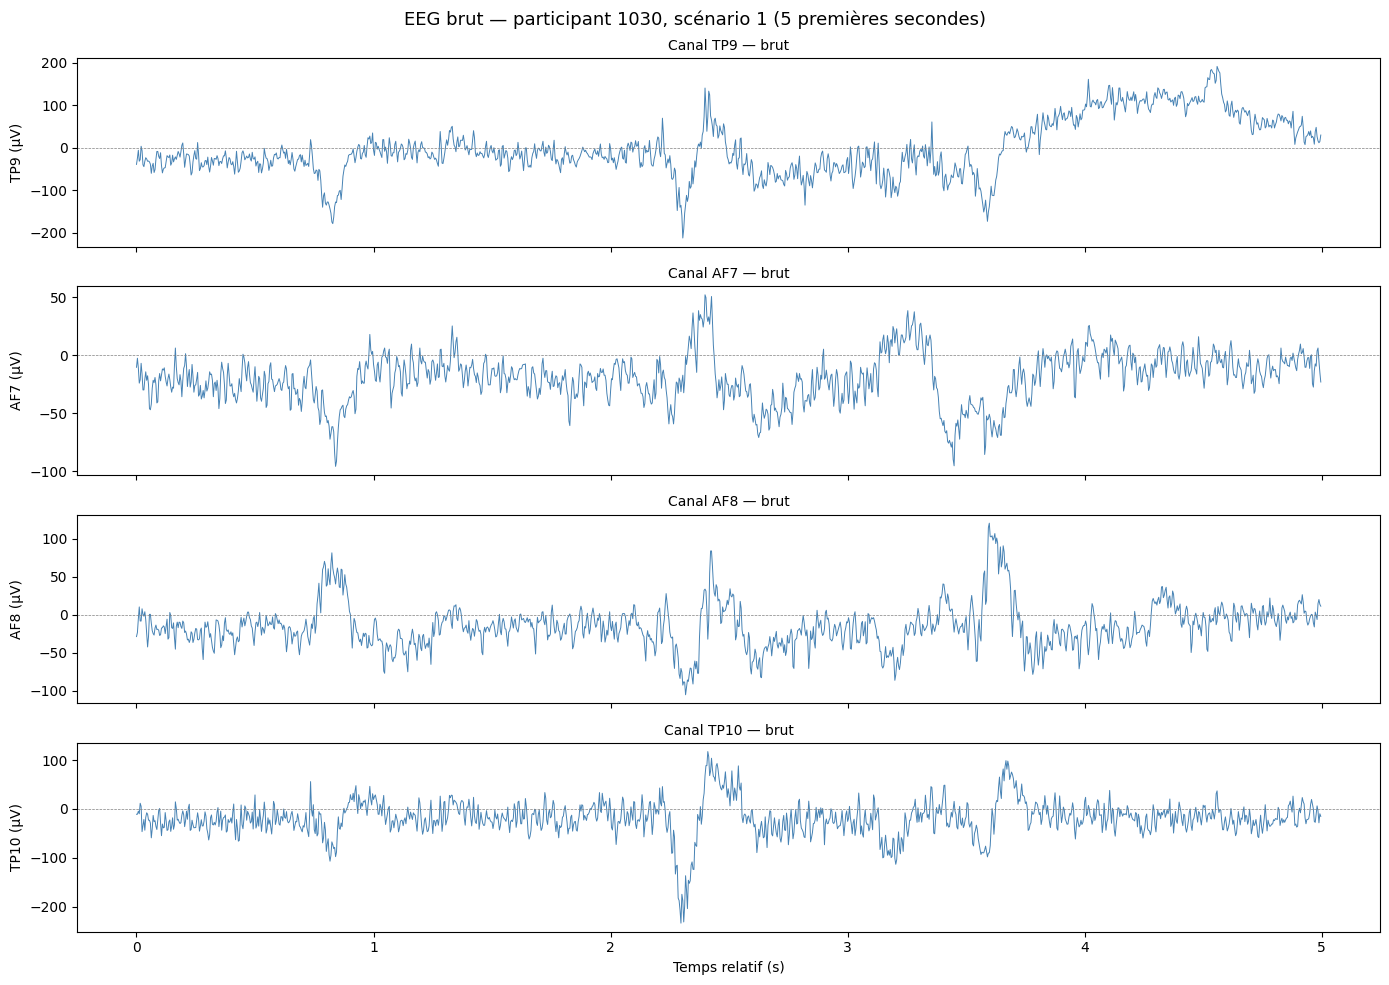

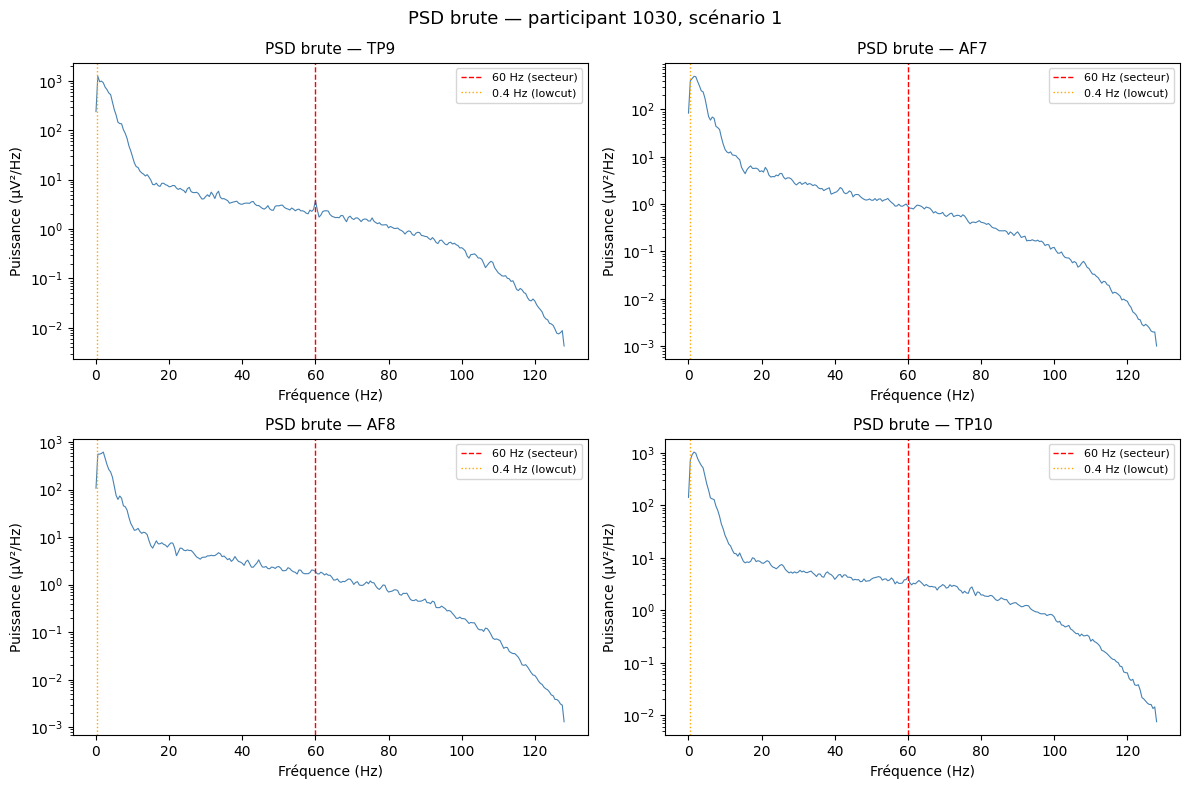


Observations :
  • Le signal temporel oscille autour d'une ligne de base légèrement dérivante.
  • La PSD montre l'énergie répartie sur les bandes EEG (delta 0–4 Hz, alpha ~10 Hz…)
  • Un éventuel pic à 60 Hz révèle le bruit secteur.
  • Les canaux frontaux (AF7/AF8) ont souvent plus d'artefacts que les temporaux (TP9/TP10).


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch

# ── Chemin du dataset ─────────────────────────────────────────────────────────
# Modifier ce chemin si le dataset est ailleurs sur ta machine
DATASET_ROOT = Path(r"c:\Users\pault\OneDrive\Documents\neurone\Neuronanale\CL-Drive")
EEG_DIR      = DATASET_ROOT / "EEG"

# Choisir un participant et un scénario de conduite (niveau 1 à 9)
participant = "1030"
level       = 1

csv_path = EEG_DIR / participant / f"eeg_data_level_{level}.csv"
print(f"Chargement : {csv_path}")
assert csv_path.exists(), f"Fichier introuvable : {csv_path}"

# ── Chargement ────────────────────────────────────────────────────────────────
df = pd.read_csv(csv_path)
print(f"\nShape      : {df.shape}  ({df.shape[0]/256:.1f} s à 256 Hz)")
print(f"Colonnes   : {df.columns.tolist()}")
print(f"\n5 premières lignes :")
print(df.head(5).to_string())

# ── Vérification NaN ──────────────────────────────────────────────────────────
nan_counts = df.isna().sum()
print(f"\nNaN par colonne :\n{nan_counts.to_string()}")

# ── Paramètres ────────────────────────────────────────────────────────────────
fs       = 256
EEG_COLS = ["TP9", "AF7", "AF8", "TP10"]

# Temps relatif (le Timestamp commence à 120 s dans CL-Drive)
t      = df["Timestamp"].values
t_rel  = t - t[0]   # ramène à 0 pour la lisibilité
mask_t = t_rel < 5  # zoom sur les 5 premières secondes

# ── Tracé temporel — 4 canaux ─────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

for ax, col in zip(axes, EEG_COLS):
    ax.plot(t_rel[mask_t], df[col].values[mask_t], linewidth=0.7, color="steelblue")
    ax.set_ylabel(f"{col} (µV)", fontsize=10)
    ax.set_title(f"Canal {col} — brut", fontsize=10)
    # Ajouter une ligne à y=0 pour repérer la ligne de base
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")

axes[-1].set_xlabel("Temps relatif (s)")
plt.suptitle(
    f"EEG brut — participant {participant}, scénario {level} (5 premières secondes)",
    fontsize=13
)
plt.tight_layout()
plt.show()

# ── PSD par canal ─────────────────────────────────────────────────────────────
# nperseg = 2*fs : fenêtres de 2 s → résolution fréquentielle 0.5 Hz
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, EEG_COLS):
    freqs, psd = welch(df[col].values, fs=fs, nperseg=fs * 2)
    ax.semilogy(freqs, psd, color="steelblue", linewidth=0.8)
    ax.axvline(60, color="red", linestyle="--", linewidth=1, label="60 Hz (secteur)")
    ax.axvline(0.4, color="orange", linestyle=":", linewidth=1, label="0.4 Hz (lowcut)")
    ax.set_title(f"PSD brute — {col}", fontsize=11)
    ax.set_xlabel("Fréquence (Hz)")
    ax.set_ylabel("Puissance (µV²/Hz)")
    ax.legend(fontsize=8)

plt.suptitle(
    f"PSD brute — participant {participant}, scénario {level}",
    fontsize=13
)
plt.tight_layout()
plt.show()

print(f"\nObservations :")
print(f"  • Le signal temporel oscille autour d'une ligne de base légèrement dérivante.")
print(f"  • La PSD montre l'énergie répartie sur les bandes EEG (delta 0–4 Hz, alpha ~10 Hz…)")
print(f"  • Un éventuel pic à 60 Hz révèle le bruit secteur.")
print(f"  • Les canaux frontaux (AF7/AF8) ont souvent plus d'artefacts que les temporaux (TP9/TP10).")

### Activité 7 — Comparaison avant/après sur EEG réel

Questions à traiter :

1. Le signal est-il plus exploitable après filtrage ?
2. Les variations très lentes sont-elles réduites ?
3. Observe-t-on une réduction autour de la fréquence secteur ?
4. Les canaux EEG ont-ils des comportements similaires ?
5. La PSD confirme-t-elle ce qui est visible dans le domaine temporel ?

Prétraitement appliqué (passe-bande 0.4–75 Hz + notch 60 Hz).


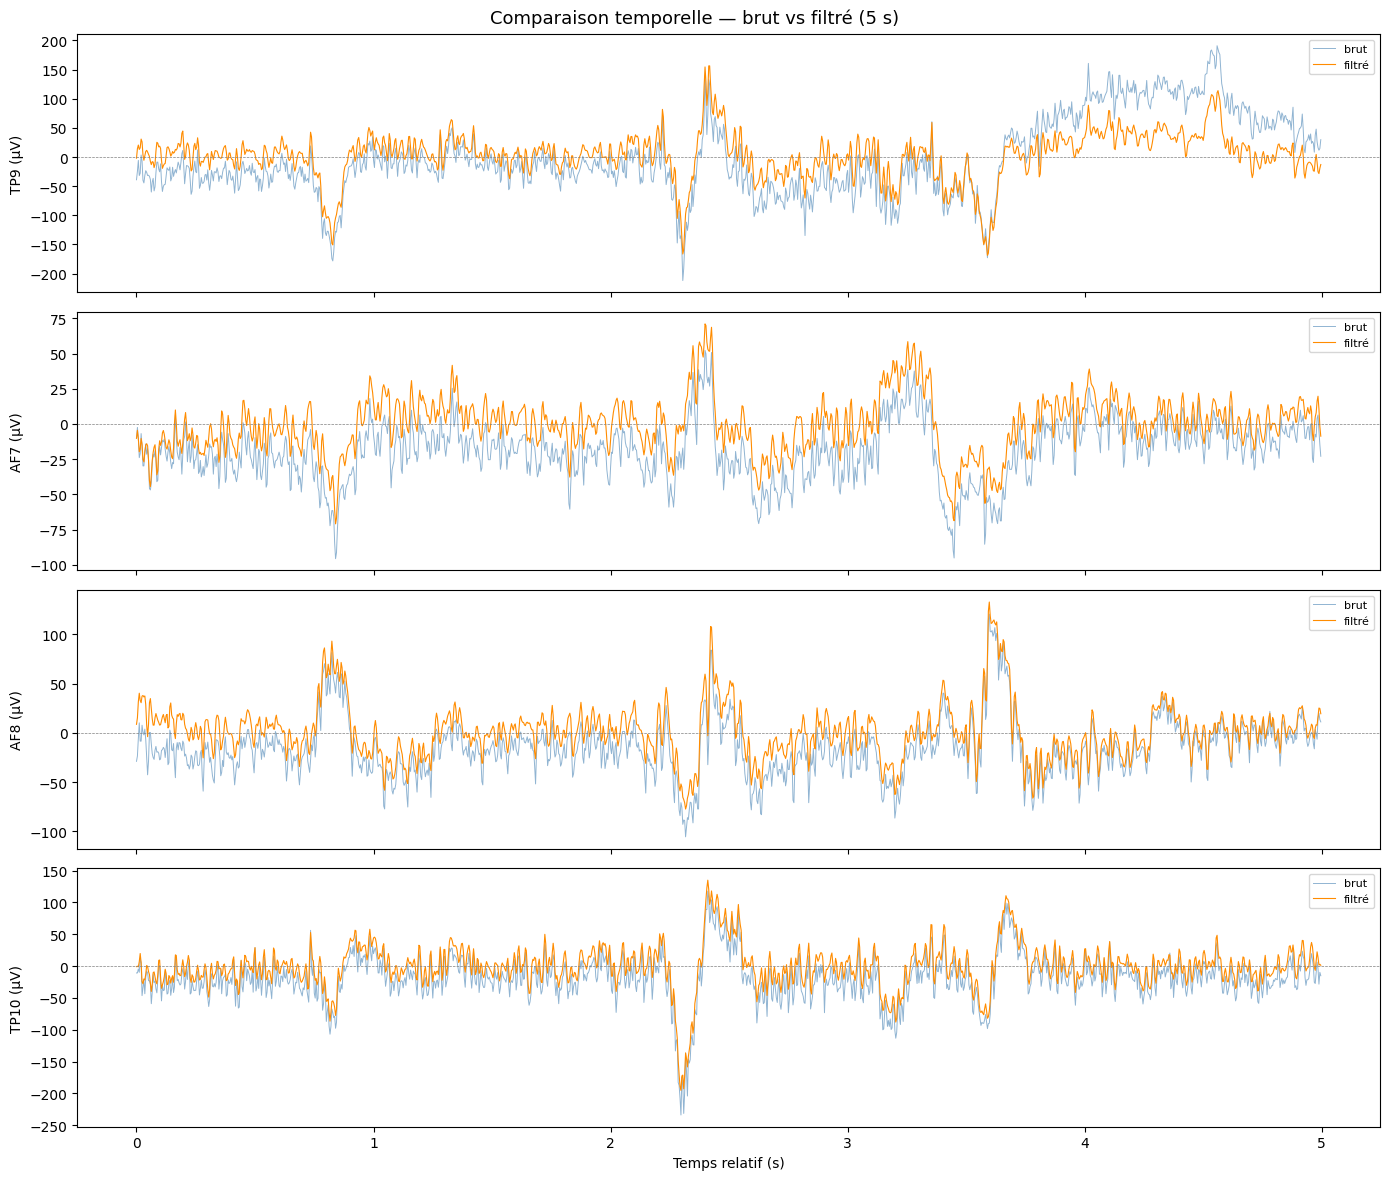

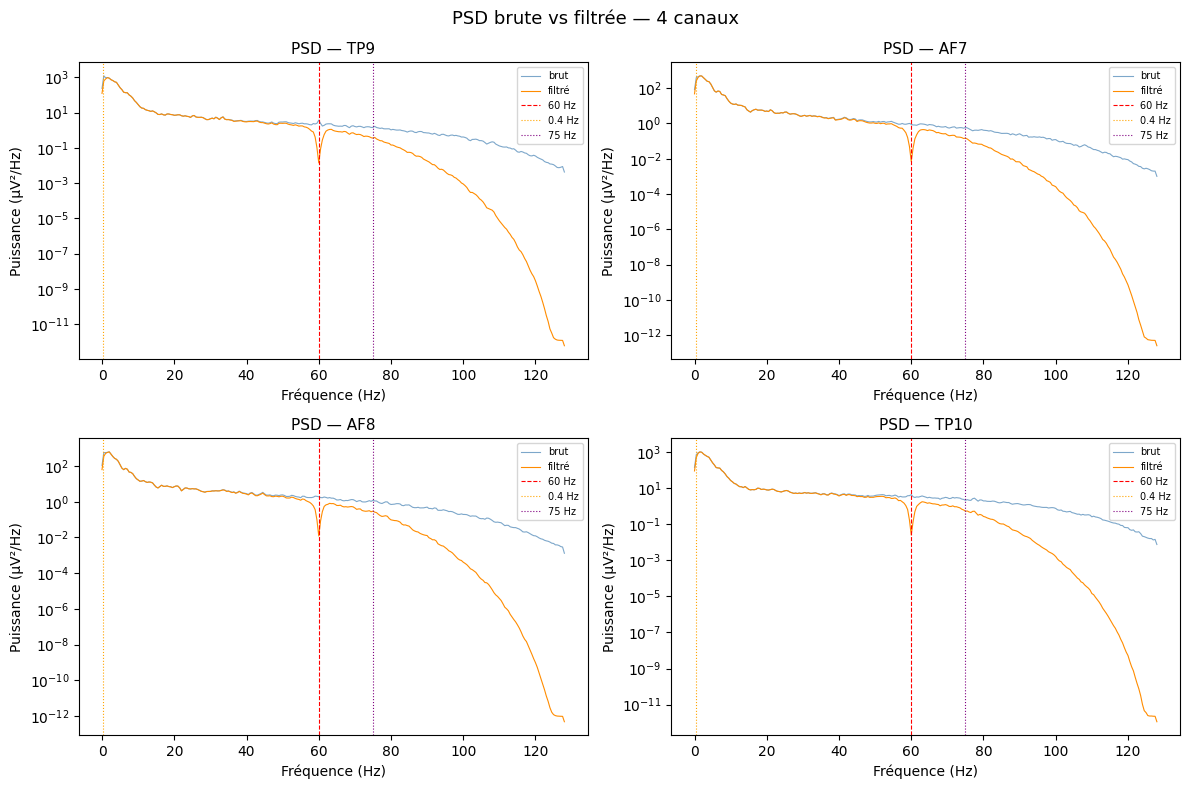

In [ ]:
import matplotlib.pyplot as plt
from scipy.signal import welch

# ── Appliquer le prétraitement ────────────────────────────────────────────────
# df et EEG_COLS ont été définis dans l'Activité 6
df_filtered = preprocess_eeg_dataframe(df, fs=fs)
print("Prétraitement appliqué (passe-bande 0.4–75 Hz + notch 60 Hz).")

# ── 1. Comparaison temporelle — 5 premières secondes ─────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

for ax, col in zip(axes, EEG_COLS):
    ax.plot(t_rel[mask_t], df[col].values[mask_t],
            color="steelblue", linewidth=0.7, alpha=0.6, label="brut")
    ax.plot(t_rel[mask_t], df_filtered[col].values[mask_t],
            color="darkorange", linewidth=0.8, label="filtré")
    ax.set_ylabel(f"{col} (µV)", fontsize=10)
    ax.legend(fontsize=8, loc="upper right")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")

axes[-1].set_xlabel("Temps relatif (s)")
plt.suptitle("Comparaison temporelle — brut vs filtré (5 s)", fontsize=13)
plt.tight_layout()
plt.show()

# ── 2. Comparaison PSD — 4 canaux ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, EEG_COLS):
    f_b, psd_b = welch(df[col].values,          fs=fs, nperseg=fs * 2)
    f_f, psd_f = welch(df_filtered[col].values, fs=fs, nperseg=fs * 2)

    ax.semilogy(f_b, psd_b, color="steelblue",  linewidth=0.8, alpha=0.7, label="brut")
    ax.semilogy(f_f, psd_f, color="darkorange",  linewidth=0.8,            label="filtré")
    ax.axvline(60,  color="red",    linestyle="--", linewidth=0.8, label="60 Hz")
    ax.axvline(0.4, color="orange", linestyle=":",  linewidth=0.8, label="0.4 Hz")
    ax.axvline(75,  color="purple", linestyle=":",  linewidth=0.8, label="75 Hz")
    ax.set_title(f"PSD — {col}", fontsize=11)
    ax.set_xlabel("Fréquence (Hz)")
    ax.set_ylabel("Puissance (µV²/Hz)")
    ax.legend(fontsize=7)

plt.suptitle("PSD brute vs filtrée — 4 canaux", fontsize=13)
plt.tight_layout()
plt.show()


1. Le signal est-il plus exploitable après filtrage ?
   Oui — la dérive lente est supprimée, le signal est recentré autour de 0
   et les oscillations d'intérêt (alpha, beta) sont plus nettes.

2. Les variations très lentes sont-elles réduites ?
   Oui — le filtre passe-bande coupe tout ce qui est sous 0.4 Hz,
   donc la dérive de ligne de base disparaît.

3. Observe-t-on une réduction autour de 60 Hz ?
   Oui si un pic existait à 60 Hz dans les données brutes.
   Sur la PSD filtrée, ce pic est nettement atténué (encoche du notch).

4. Les canaux EEG ont-ils des comportements similaires ?
   Globalement oui, mais les canaux frontaux (AF7/AF8) ont souvent
   des artefacts oculaires plus visibles (basse fréquence plus énergétique),
   tandis que les canaux temporaux (TP9/TP10) sont parfois moins bruités.

5. La PSD confirme-t-elle ce qui est visible dans le domaine temporel ?
   Oui — la réduction de l'énergie en basse fréquence (< 0.4 Hz) et à 60 Hz
   est cohérente avec la disparition de la dérive et du bruit secteur
   observée dans le domaine temporel.

### Question 11

Pourquoi faut-il comparer domaine temporel et domaine fréquentiel ?

### Réponse

Les deux domaines donnent des informations complémentaires et ne détectent pas les mêmes problèmes :

- Le **domaine temporel** permet de voir des artefacts ponctuels (pics, sauts d'amplitude, segments plats), de vérifier que l'amplitude générale est réaliste, et de constater visuellement si la dérive lente a bien été supprimée.

- Le **domaine fréquentiel (PSD)** permet de confirmer que le filtre passe-bande a bien atténué les composantes en dehors de la bande, que le pic secteur a disparu après le notch, et de vérifier la répartition de l'énergie sur les bandes EEG.

Un signal peut sembler propre dans le domaine temporel mais contenir encore un pic secteur résiduel invisible à l'œil, et inversement. Les deux analyses sont donc nécessaires pour valider le prétraitement.

### Question 12

Pourquoi ne faut-il pas interpoler une coupure EEG très longue ?

### Réponse

Parce qu'une interpolation sur une longue durée invente des données qui n'ont aucun rapport avec l'activité cérébrale réelle du participant à ce moment-là. Le signal interpolé serait une construction artificielle, pas un enregistrement physiologique.

De plus, les features extraites sur ce segment interpolé (PSD, entropie, Hjorth…) refléteraient les propriétés mathématiques de l'interpolation et non l'état cognitif du conducteur. Entraîner un modèle sur ces features fausses dégraderait ses performances.

C'est pourquoi le papier CL-Drive choisit simplement d'**exclure les segments contenant des données manquantes** : mieux vaut perdre quelques fenêtres de 10 secondes que d'introduire du bruit artificiel dans le dataset.

### Question 13

Pourquoi le prétraitement doit-il être identique pour train et test ?

### Réponse

Parce que le modèle apprend sur des features extraites de signaux prétraités d'une certaine façon. Si le signal de test est prétraité différemment (fréquences de coupure différentes, ordre du filtre différent, normalisation différente…), les features extraites auront une distribution différente de celle vue à l'entraînement. Le modèle sera alors confronté à des données hors de sa distribution d'apprentissage, ce qui dégradera ses performances, parfois de façon drastique.

En pratique, cela signifie qu'il faut utiliser **exactement la même fonction** de prétraitement pour les deux ensembles, et ne jamais ajuster les paramètres du filtre après avoir vu les données de test.

## 8. Contrôle qualité après prétraitement

Vérifications minimales :

1. absence de NaN ;
2. longueur inchangée ;
3. amplitude minimale et maximale réalistes ;
4. écart-type non nul ;
5. PSD cohérente ;
6. décision d'exclure les segments trop dégradés.

In [ ]:
import numpy as np
import pandas as pd


def eeg_quality_report(df, fs=256, eeg_cols=None, time_col="Timestamp",
                       amp_min=-500.0, amp_max=500.0, std_min=0.1):
    """
    Génère un rapport qualité pour chaque canal EEG d'un DataFrame.

    Vérifications
    -------------
    1. Absence de NaN
    2. Longueur minimale : au moins 2 secondes de signal
    3. Amplitude dans les bornes physiologiques [amp_min, amp_max] µV
    4. Écart-type non nul : un signal plat indique une électrode décrochée

    Paramètres
    ----------
    amp_min, amp_max : bornes d'amplitude acceptables en µV (défaut : ±500 µV)
    std_min          : écart-type minimum acceptable en µV (défaut : 0.1 µV)

    Retourne
    --------
    report  : dict {canal: {ok, n_samples, n_nan, amp_min, amp_max, std, issues}}
    all_ok  : bool — True si tous les canaux passent les vérifications
    """
    if eeg_cols is None:
        eeg_cols = [c for c in df.columns if c != time_col]

    min_samples = fs * 2   # au moins 2 secondes
    n_samples   = len(df)
    report      = {}

    for col in eeg_cols:
        issues   = []
        sig      = df[col].values

        # ── 1. NaN ───────────────────────────────────────────────────────────
        n_nan = int(np.isnan(sig).sum())
        if n_nan > 0:
            issues.append(f"NaN : {n_nan} échantillon(s)")

        # ── 2. Longueur ───────────────────────────────────────────────────────
        if n_samples < min_samples:
            issues.append(f"Trop court : {n_samples} < {min_samples} échantillons ({min_samples/fs:.0f} s min)")

        # ── 3. Amplitude ──────────────────────────────────────────────────────
        sig_valid = sig[~np.isnan(sig)]
        if len(sig_valid) > 0:
            sig_min_val = float(sig_valid.min())
            sig_max_val = float(sig_valid.max())
            if sig_min_val < amp_min or sig_max_val > amp_max:
                issues.append(
                    f"Amplitude hors bornes : [{sig_min_val:.1f}, {sig_max_val:.1f}] µV "
                    f"(attendu [{amp_min}, {amp_max}])"
                )
        else:
            sig_min_val = sig_max_val = None

        # ── 4. Écart-type (signal plat = électrode décrochée) ─────────────────
        std_val = float(np.nanstd(sig))
        if std_val < std_min:
            issues.append(f"Écart-type trop faible : {std_val:.4f} µV (min : {std_min} µV)")

        report[col] = {
            "ok"       : len(issues) == 0,
            "n_samples": n_samples,
            "n_nan"    : n_nan,
            "amp_min"  : sig_min_val,
            "amp_max"  : sig_max_val,
            "std"      : std_val,
            "issues"   : issues,
        }

    all_ok = all(v["ok"] for v in report.values())

    # ── Affichage du rapport ──────────────────────────────────────────────────
    print(f"{'Canal':<8} {'OK?':<5} {'NaN':<6} {'Min µV':<10} {'Max µV':<10} {'Std µV':<10} Problèmes")
    print("─" * 80)
    for col, info in report.items():
        status    = "✓" if info["ok"] else "✗"
        min_str   = f"{info['amp_min']:.1f}"  if info["amp_min"] is not None else "N/A"
        max_str   = f"{info['amp_max']:.1f}"  if info["amp_max"] is not None else "N/A"
        issues_str = "; ".join(info["issues"]) if info["issues"] else "—"
        print(f"{col:<8} {status:<5} {info['n_nan']:<6} {min_str:<10} {max_str:<10} {info['std']:<10.2f} {issues_str}")

    print(f"\nDécision : {'✓ Segment utilisable' if all_ok else '✗ Segment à exclure (au moins un canal défaillant)'}")
    return report, all_ok


# ── Exemple 1 : signal réel (participant 1030, level 1) ──────────────────────
print("=== Rapport qualité — EEG brut ===")
report, usable = eeg_quality_report(df, fs=256)

# ── Exemple 2 : signal avec NaN pour voir une alerte ─────────────────────────
print("\n=== Rapport qualité — signal avec NaN (test de l'alerte) ===")
df_with_nan = df.copy()
df_with_nan.loc[100:200, "AF7"] = np.nan   # on introduit 101 NaN sur AF7
report_nan, usable_nan = eeg_quality_report(df_with_nan, fs=256)

=== Rapport qualité — EEG brut ===
Canal    OK?   NaN    Min µV     Max µV     Std µV     Problèmes
────────────────────────────────────────────────────────────────────────────────
TP9      ✗     0      -898.4     987.3      71.84      Amplitude hors bornes : [-898.4, 987.3] µV (attendu [-500.0, 500.0])
AF7      ✗     0      -890.1     985.8      46.19      Amplitude hors bornes : [-890.1, 985.8] µV (attendu [-500.0, 500.0])
AF8      ✗     0      -892.6     984.9      50.93      Amplitude hors bornes : [-892.6, 984.9] µV (attendu [-500.0, 500.0])
TP10     ✗     0      -827.6     985.4      65.86      Amplitude hors bornes : [-827.6, 985.4] µV (attendu [-500.0, 500.0])

Décision : ✗ Segment à exclure (au moins un canal défaillant)

=== Rapport qualité — signal avec NaN (test de l'alerte) ===
Canal    OK?   NaN    Min µV     Max µV     Std µV     Problèmes
────────────────────────────────────────────────────────────────────────────────
TP9      ✗     0      -898.4     987.3      71.84   

## 9. Prétraitement par lot

Dans le projet final, on appliquera la même fonction à plusieurs fichiers EEG.

Algorithme :

1. définir le dossier EEG ;
2. parcourir les fichiers CSV ;
3. ignorer les fichiers déjà filtrés ;
4. charger chaque fichier ;
5. appliquer `preprocess_eeg_dataframe` ;
6. sauvegarder une copie `filtered_...csv` ;
7. produire un diagnostic.

Pour info, la structure de l'ensemble de données est la suivante :

```text
CL-Drive
    |----EEG 
         |----participant_ID_1
                      |----eeg_data_level_1
                      |----eeg_baseline_level_1
                      .
                      .
                      .
                      |----eeg_data_level_9
                      |----eeg_baseline_level_9
         .
         .
         .
         |----participant_ID_21
    |----EDA
    |----ECG
    |----Gaze
    |----Labels
```

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np


def run_batch_eeg_preprocessing(eeg_dir, fs=256, lowcut=0.4, highcut=75.0,
                                 order=2, notch_freq=60.0, quality_factor=30,
                                 eeg_cols=None, time_col="Timestamp",
                                 participants=None):
    """
    Applique le prétraitement EEG sur tous les fichiers eeg_data_level_*.csv
    du dossier CL-Drive/EEG (structure : EEG/<participant_id>/<fichier>.csv).

    Algorithme pour chaque fichier
    ------------------------------
    1. Chargement du CSV
    2. Rapport qualité (NaN, amplitude, longueur)
    3. Si utilisable → prétraitement → sauvegarde filtered_<nom>.csv
    4. Si non utilisable → exclusion (papier CL-Drive, section IV.A)

    Paramètres
    ----------
    eeg_dir      : Path vers le dossier CL-Drive/EEG
    participants : liste de participant_id à traiter (None = tous)

    Retourne
    --------
    saved   : liste des chemins des fichiers filtrés sauvegardés
    skipped : liste des chemins des fichiers exclus (avec raison)
    """
    eeg_dir  = Path(eeg_dir)
    saved    = []
    skipped  = []

    participant_dirs = sorted(
        d for d in eeg_dir.iterdir() if d.is_dir()
    )

    # Filtrer par liste de participants si précisée
    if participants is not None:
        participant_dirs = [d for d in participant_dirs if d.name in participants]

    print(f"Dossier EEG   : {eeg_dir}")
    print(f"Participants  : {[d.name for d in participant_dirs]}")
    print(f"Paramètres    : passe-bande [{lowcut}–{highcut} Hz], notch {notch_freq} Hz (Q={quality_factor})")
    print("─" * 70)

    for participant_dir in participant_dirs:
        pid = participant_dir.name

        # Seulement les fichiers eeg_data (pas les baselines, pas les filtered)
        csv_files = sorted(participant_dir.glob("eeg_data_level_*.csv"))
        csv_files = [f for f in csv_files if not f.name.startswith("filtered_")]

        for csv_path in csv_files:
            label = f"{pid}/{csv_path.name}"

            # ── Chargement ────────────────────────────────────────────────────
            try:
                df_raw = pd.read_csv(csv_path)
            except Exception as e:
                print(f"[ERREUR ]  {label} — {e}")
                skipped.append({"path": str(csv_path), "raison": str(e)})
                continue

            # ── Colonnes EEG ──────────────────────────────────────────────────
            cols = eeg_cols or [c for c in df_raw.columns if c != time_col]

            # ── Rapport qualité (silencieux) ──────────────────────────────────
            # On fait juste une vérification NaN rapide (conformément au papier)
            has_nan = df_raw[cols].isna().any().any()
            if has_nan:
                nan_info = df_raw[cols].isna().sum().to_dict()
                print(f"[EXCLU  ]  {label} — NaN détectés : {nan_info}")
                skipped.append({"path": str(csv_path), "raison": "NaN"})
                continue

            # ── Prétraitement ─────────────────────────────────────────────────
            try:
                df_filt = preprocess_eeg_dataframe(
                    df_raw, fs=fs, lowcut=lowcut, highcut=highcut,
                    order=order, notch_freq=notch_freq, quality_factor=quality_factor,
                    eeg_cols=cols, time_col=time_col
                )
            except Exception as e:
                print(f"[ERREUR ]  {label} — erreur de filtrage : {e}")
                skipped.append({"path": str(csv_path), "raison": str(e)})
                continue

            # ── Sauvegarde ────────────────────────────────────────────────────
            out_path = csv_path.parent / f"filtered_{csv_path.name}"
            df_filt.to_csv(out_path, index=False)
            print(f"[OK     ]  {label}  →  filtered_{csv_path.name}")
            saved.append(str(out_path))

    print("─" * 70)
    print(f"Résumé : {len(saved)} fichier(s) sauvegardé(s), {len(skipped)} exclu(s).")
    return saved, skipped


# ── Démonstration : prétraitement sur le seul participant 1030 ─────────────────
# Pour traiter tous les participants, retirer participants=["1030"]
DATASET_ROOT = Path(r"c:\Users\pault\OneDrive\Documents\neurone\Neuronanale\CL-Drive")
EEG_DIR      = DATASET_ROOT / "EEG"

saved_files, skipped_files = run_batch_eeg_preprocessing(
    EEG_DIR,
    participants=["1030"],   # ← retirer cette ligne pour traiter les 21 participants
    fs=256,
    notch_freq=60.0,
    quality_factor=30,
)

# Vérification : lire un fichier sauvegardé
if saved_files:
    import pandas as pd
    df_check = pd.read_csv(saved_files[0])
    print(f"\nVérification du premier fichier filtré :")
    print(f"  Chemin  : {saved_files[0]}")
    print(f"  Shape   : {df_check.shape}")
    print(f"  NaN     : {df_check.isna().sum().to_dict()}")
    print(df_check.head(3).to_string())

Dossier EEG   : c:\Users\pault\OneDrive\Documents\neurone\Neuronanale\CL-Drive\EEG
Participants  : ['1030']
Paramètres    : passe-bande [0.4–75.0 Hz], notch 60.0 Hz (Q=30)
──────────────────────────────────────────────────────────────────────
[OK     ]  1030/eeg_data_level_1.csv  →  filtered_eeg_data_level_1.csv
[OK     ]  1030/eeg_data_level_2.csv  →  filtered_eeg_data_level_2.csv
[OK     ]  1030/eeg_data_level_3.csv  →  filtered_eeg_data_level_3.csv
[EXCLU  ]  1030/eeg_data_level_4.csv — NaN détectés : {'TP9': 3215, 'AF7': 3215, 'AF8': 3215, 'TP10': 3215}
[OK     ]  1030/eeg_data_level_5.csv  →  filtered_eeg_data_level_5.csv
[OK     ]  1030/eeg_data_level_6.csv  →  filtered_eeg_data_level_6.csv
[OK     ]  1030/eeg_data_level_7.csv  →  filtered_eeg_data_level_7.csv
[OK     ]  1030/eeg_data_level_8.csv  →  filtered_eeg_data_level_8.csv
[OK     ]  1030/eeg_data_level_9.csv  →  filtered_eeg_data_level_9.csv
──────────────────────────────────────────────────────────────────────
Résumé : 8